# Heat Flow vs Total Variation Flow

## Linear heat flow

The heat equation $\partial_t u = \Delta u$ is the gradient flow of the **Dirichlet energy** $E_2(u) = \frac{1}{2}\int |\nabla u|^2$ in $L^2$. It is **linear** and smooths everything uniformly — edges are blurred.

## Total variation flow

The **TV flow** is the gradient flow of the **total variation** $E_1(u) = \int |\nabla u|$ in $L^2$:
$$
\partial_t u = \mathrm{div}\left(\frac{\nabla u}{|\nabla u|}\right).
$$
This is a **nonlinear PDE** (singular at $\nabla u = 0$). It:
- Preserves sharp edges (unlike the heat equation).
- Flattens piecewise-constant regions instantly.
- Exhibits **finite extinction time**: bounded signals reach $u \equiv \mathrm{const}$ in finite time.

## Comparison

| | Heat flow | TV flow |
|---|---|---|
| Linearity | Linear | Nonlinear |
| Edge behaviour | Blurs edges | Preserves edges |
| Flat regions | Unchanged | Flattened |
| Extinction | $t \to \infty$ | Finite $T^* < \infty$ |
| PDE type | Parabolic, linear | Parabolic, degenerate |

## Numerical implementation

TV flow is solved via the **split Bregman** or **semi-implicit scheme**: replace $|\nabla u|$ by $\sqrt{|\nabla u|^2 + \varepsilon^2}$ (regularised TV) to avoid the singularity.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatLogSlider, FloatSlider

plt.rcParams['figure.dpi'] = 120

## 1D flows

We implement both flows on a 1D signal using forward Euler (heat) and semi-implicit (TV).

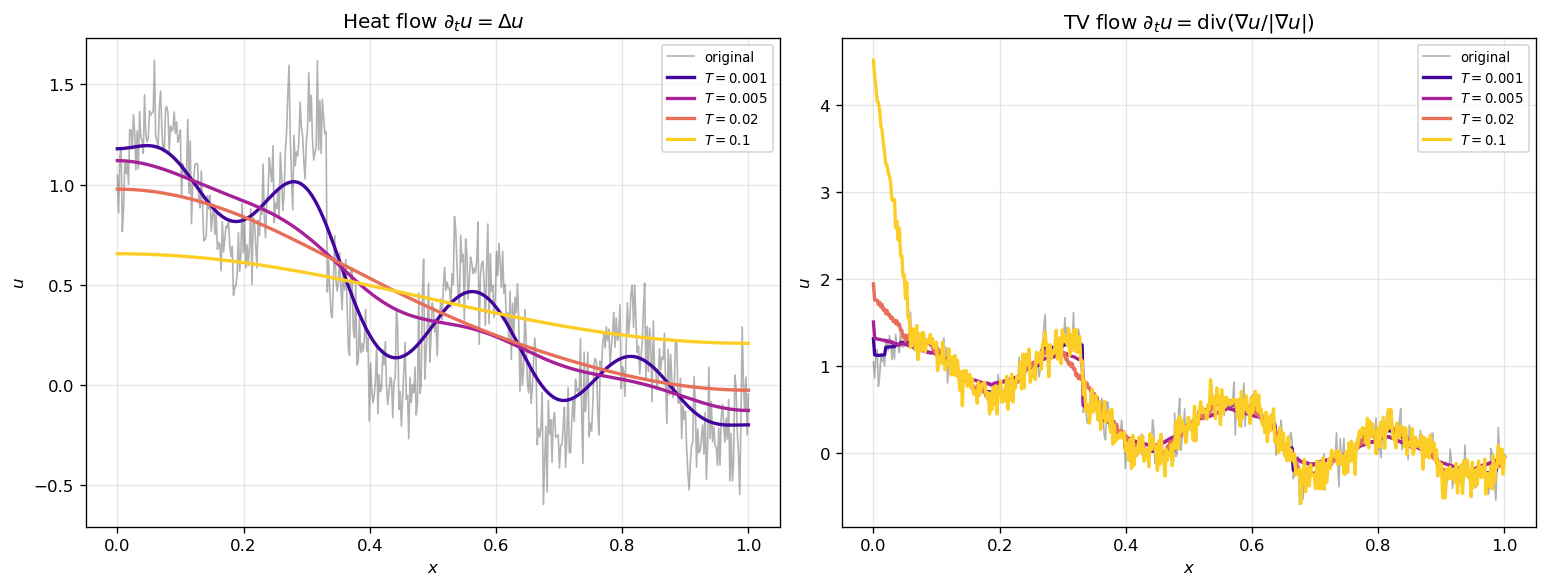

In [2]:
N = 512
x = np.linspace(0, 1, N)
dx = x[1] - x[0]

def laplacian_1d(u):
    """1D Laplacian with Neumann BC."""
    d = np.zeros_like(u)
    d[1:-1] = u[2:] - 2*u[1:-1] + u[:-2]
    d[0]    = u[1] - u[0]
    d[-1]   = u[-2] - u[-1]
    return d / dx**2

def tv_div_1d(u, eps=0.01):
    """div(grad u / |grad u|_eps) in 1D: d/dx(u' / sqrt(u'^2 + eps^2))."""
    du = np.zeros_like(u)
    du[:-1] = np.diff(u) / dx
    du[-1] = du[-2]  # Neumann
    ndu = np.sqrt(du**2 + eps**2)
    flux = du / ndu
    div_flux = np.zeros_like(u)
    div_flux[1:] = np.diff(flux) / dx
    div_flux[0] = div_flux[1]
    return div_flux

def run_heat_1d(f, T, n_steps):
    dt = T / n_steps; u = f.copy(); hist = [f.copy()]
    # Stability: dt <= dx^2/2
    dt = min(dt, 0.4 * dx**2)
    t = 0
    while t < T:
        u = u + dt * laplacian_1d(u); t += dt
    return u

def run_tv_1d(f, T, n_steps, eps=0.01):
    dt = T / n_steps; u = f.copy()
    for _ in range(n_steps):
        u = u + dt * tv_div_1d(u, eps)
    return u

# Signal: piecewise constant + smooth bump + noise
rng = np.random.default_rng(42)
f0 = np.zeros(N)
f0[:N//3] = 1.0; f0[N//3:2*N//3] = 0.3
f0 += 0.3 * np.sin(8*np.pi*x)
f0 += 0.15 * rng.standard_normal(N)

t_values = [0.001, 0.005, 0.02, 0.1]
cols = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, label, fn in zip(axes, ['Heat flow $\\partial_t u = \\Delta u$', 'TV flow $\\partial_t u = \\mathrm{div}(\\nabla u/|\\nabla u|)$'],
                               [run_heat_1d, run_tv_1d]):
    ax.plot(x, f0, 'k-', lw=1, alpha=0.3, label='original')
    for T, col in zip(t_values, cols):
        u = fn(f0, T, 500)
        ax.plot(x, u, color=col, lw=2, label=f'$T={T}$')
    ax.set_title(label); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlabel('$x$'); ax.set_ylabel('$u$')
plt.tight_layout(); plt.show()

## 2D flows on images

We apply both flows to a 2D image (synthetic) and compare the smoothing effects.

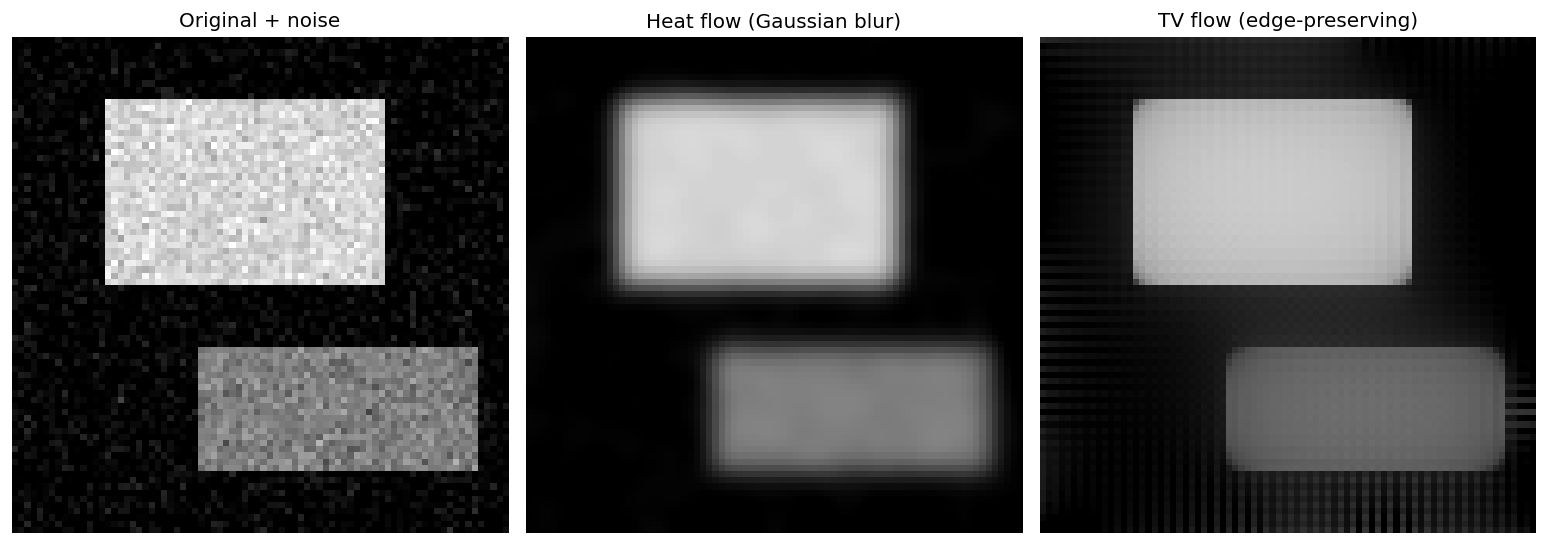

In [3]:
n2d = 80
x2 = np.linspace(0, 1, n2d)
X2, Y2 = np.meshgrid(x2, x2)

# Piecewise image with edges
img = np.zeros((n2d, n2d))
img[10:40, 15:60] = 1.0
img[50:70, 30:75] = 0.6
img += 0.08 * np.random.default_rng(7).standard_normal((n2d, n2d))

from scipy.ndimage import gaussian_filter

def tv_step_2d(u, dt, eps=0.01):
    dy, dx = np.gradient(u)
    norm = np.sqrt(dx**2 + dy**2 + eps**2)
    flux_x = dx / norm; flux_y = dy / norm
    dfx = np.gradient(flux_x, axis=1)
    dfy = np.gradient(flux_y, axis=0)
    return u + dt * (dfx + dfy)

# Heat (Gaussian blur)
img_heat = gaussian_filter(img, sigma=2.0)

# TV flow
u_tv = img.copy()
for _ in range(100):
    u_tv = tv_step_2d(u_tv, dt=0.01)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (im, title) in zip(axes, [
    (img, 'Original + noise'),
    (img_heat, 'Heat flow (Gaussian blur)'),
    (u_tv, 'TV flow (edge-preserving)'),
]):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1.2)
    ax.axis('off'); ax.set_title(title)

plt.tight_layout(); plt.show()

## Interactive: compare flows on 1D signal

In [4]:
def show_flows(log_T=-2.0, eps_tv=0.01):
    T_i = 10**log_T
    u_heat = run_heat_1d(f0, T_i, 500)
    u_tv_i = run_tv_1d(f0, T_i, 500, eps=eps_tv)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(x, f0, 'k-', lw=1, alpha=0.3, label='original')
    ax.plot(x, u_heat, 'royalblue', lw=2, label=f'Heat flow (T={T_i:.4f})')
    ax.plot(x, u_tv_i, 'tomato', lw=2, label=f'TV flow (T={T_i:.4f})')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_xlabel('$x$'); ax.set_ylabel('$u$')
    ax.set_title('Heat vs TV flow comparison')
    plt.tight_layout(); plt.show()

interact(show_flows,
         log_T=FloatLogSlider(value=-2.0, min=-4.0, max=-0.5, step=0.25, description='$\\log_{10}T$'),
         eps_tv=FloatSlider(value=0.01, min=0.001, max=0.1, step=0.005, description='$\\varepsilon_{TV}$'));

interactive(children=(FloatLogSlider(value=0.0001, description='$\\log_{10}T$', max=-0.5, min=-4.0, step=0.25)…

## Bibliographical resources

- Rudin, L. I., Osher, S. and Fatemi, E. (1992). Nonlinear total variation based noise removal algorithms. *Physica D: Nonlinear Phenomena*, 60(1–4), 259–268.
- Andreu, F., Ballester, C., Caselles, V. and Mazón, J. M. (2001). Minimizing total variation flow. *Differential and Integral Equations*, 14(3), 321–360.
- Chambolle, A. (2004). An algorithm for total variation minimization and applications. *Journal of Mathematical Imaging and Vision*, 20(1–2), 89–97.
- Perona, P. and Malik, J. (1990). Scale-space and edge detection using anisotropic diffusion. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 12(7), 629–639.
- Weickert, J. (1998). *Anisotropic Diffusion in Image Processing*. Teubner.